<a href="https://colab.research.google.com/github/Khushikumari24/Chatbot/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
from collections import Counter

# Download NLTK data (free, one-time)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

print("All libraries loaded!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries loaded!


Cell 2 — Load the dataset

In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLabel counts:")
print(df['label'].value_counts())

Dataset shape: (5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64


 Explore the data (EDA)

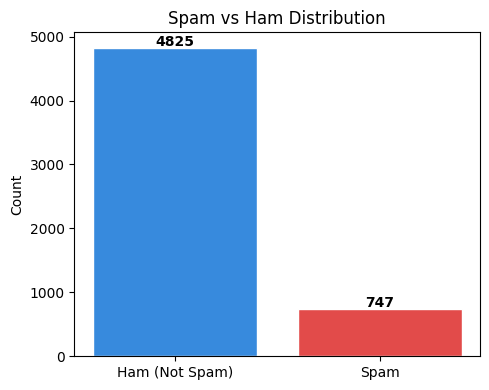


Average message length:
label
ham      71.482487
spam    138.670683
Name: msg_length, dtype: float64


In [ ]:
# How many spam vs ham?
counts = df['label'].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(['Ham (Not Spam)', 'Spam'], counts.values, color=['#378ADD', '#E24B4A'], edgecolor='white')
plt.title('Spam vs Ham Distribution')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Message length analysis
df['msg_length'] = df['message'].apply(len)
print("\nAverage message length:")
print(df.groupby('label')['msg_length'].mean())

# Spam messages are much longer on average — that's a useful feature!

Cell 4 — Data Preprocessing (NLP Basics)

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab') # Download missing resource

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Step 1: Lowercase everything
    # "FREE" and "free" should be treated as same word
    text = text.lower()

    # Step 2: Remove punctuation and special characters
    # "win!!!" → "win"
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 3: Tokenization — split sentence into list of words
    # "free money now" → ["free", "money", "now"]
    tokens = word_tokenize(text)

    # Step 4: Remove stopwords — common words that add no meaning
    # Remove: "the", "is", "a", "you", "to" etc.
    tokens = [t for t in tokens if t not in stop_words]

    # Step 5: Lemmatization — reduce word to its root form
    # "winning" → "win", "calls" → "call", "prizes" → "prize"
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Join tokens back into a clean string
    return ' '.join(tokens)

# Apply preprocessing to every message
df['clean_message'] = df['message'].apply(preprocess_text)

print("Original:  ", df['message'][0])
print("Cleaned:   ", df['clean_message'][0])
print()
print("Original:  ", df['message'][2])
print("Cleaned:   ", df['clean_message'][2])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original:   Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned:    go jurong point crazy available bugis n great world la e buffet cine got amore wat

Original:   Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned:    free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over


 Feature Engineering (creating new features from text)

In [ ]:
# These are hand-crafted features we CREATE from raw text
# This is "Feature Engineering" — using domain knowledge to help the model

df['num_words']       = df['message'].apply(lambda x: len(x.split()))
# Word count — spam tends to be wordy

df['num_chars']       = df['message'].apply(len)
# Character count — spam has long messages

df['num_exclamations']= df['message'].apply(lambda x: x.count('!'))
# Exclamation marks — spam loves "WIN NOW!!!"

df['num_uppercase']   = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()))
# Uppercase letters — spam uses "FREE OFFER"

df['num_digits']      = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
# Digits — spam has phone numbers, prize amounts

df['has_currency']    = df['message'].apply(lambda x: 1 if any(c in x for c in ['$','£','€']) else 0)
# Currency symbols — "Win £1000!"

df['has_url']         = df['message'].apply(lambda x: 1 if 'http' in x.lower() or 'www' in x.lower() else 0)
# URLs — spam often contains links

# See difference between spam and ham features
print("Feature averages by label:")
feat_cols = ['num_words','num_chars','num_exclamations','num_uppercase','num_digits','has_currency','has_url']
print(df.groupby('label')[feat_cols].mean().round(2))

Feature averages by label:
       num_words  num_chars  num_exclamations  num_uppercase  num_digits  \
label                                                                      
ham        14.31      71.48              0.18           4.11        0.31   
spam       23.91     138.67              0.73          15.47       15.81   

       has_currency  has_url  
label                         
ham            0.00     0.00  
spam           0.34     0.14  


Cell 6 — TF-IDF (convert text into numbers)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF = Term Frequency × Inverse Document Frequency
#
# TF  = how often a word appears in THIS message
# IDF = how rare the word is across ALL messages
#
# Common words like "the" → low IDF score (appears everywhere, useless)
# Rare words like "prize" → high IDF score (appears mainly in spam, very useful!)
#
# Result: each message becomes a vector of numbers

tfidf = TfidfVectorizer(
    max_features=3000,   # keep top 3000 most useful words only
    ngram_range=(1, 2),  # use single words AND pairs: "free prize", "call now"
    min_df=2             # ignore words that appear in fewer than 2 messages
)

# fit_transform on training text = learn vocabulary + convert to numbers
tfidf_matrix = tfidf.fit_transform(df['clean_message'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print(f"Each message is now a vector of {tfidf_matrix.shape[1]} numbers")
print("\nTop 20 words by TF-IDF importance (spam indicators):")
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

TF-IDF matrix shape: (5572, 3000)
Each message is now a vector of 3000 numbers

Top 20 words by TF-IDF importance (spam indicators):
['abiola' 'able' 'abt' 'ac' 'acc' 'accept' 'access' 'accidentally'
 'account' 'account statement' 'across' 'across sea' 'activate' 'actually'
 'ad' 'add' 'added' 'addicted' 'address' 'admirer']


Cell 7 — Word Embeddings (Word2Vec concept demo)

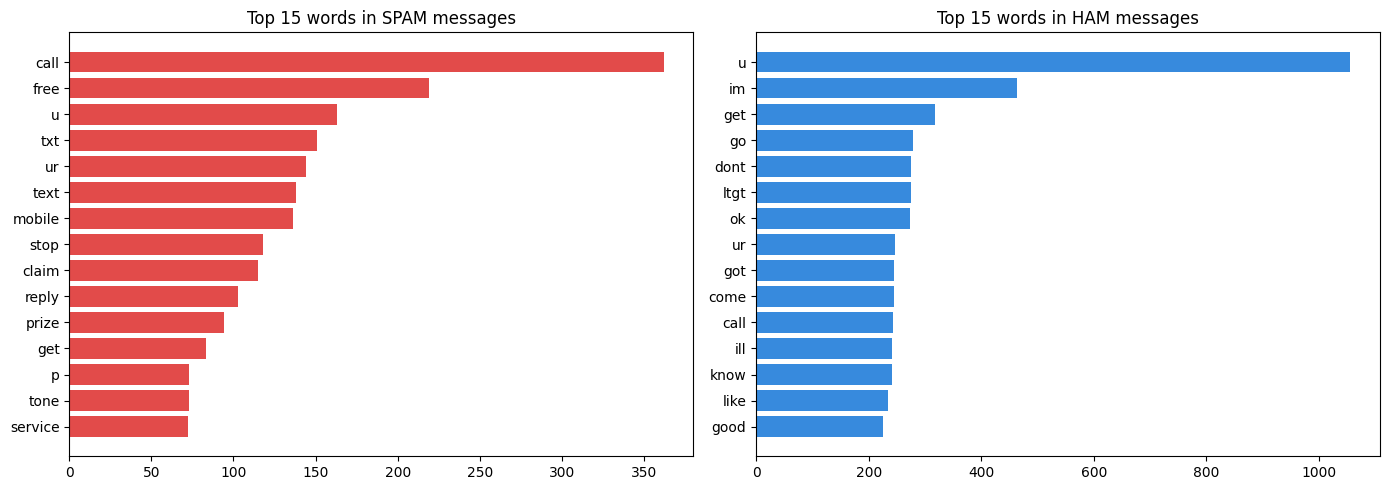

In [ ]:
# Word Embeddings = represent each word as a dense vector of numbers
# Unlike TF-IDF (sparse, just counts), embeddings capture MEANING
#
# Example:
#   "free"  → [0.82, -0.31, 0.14, ...]  (128 numbers)
#   "prize" → [0.79, -0.28, 0.18, ...]  (similar → spam-like words cluster together!)
#   "hello" → [-0.12, 0.65, -0.41, ...] (totally different direction)
#
# We use a simple average word vector as sentence representation

from sklearn.feature_extraction.text import CountVectorizer

# For Colab (free/no-GPU), we simulate embeddings using co-occurrence counts
# In real projects you'd use: gensim Word2Vec or HuggingFace sentence-transformers

# Simple approach: average TF-IDF weighted vectors (good enough for beginners!)
# This IS a form of word embedding aggregation used in production

# Show word similarity concept with top spam words
spam_messages = df[df['label'] == 'spam']['clean_message']
ham_messages  = df[df['label'] == 'ham']['clean_message']

# Most common words in spam
spam_words = ' '.join(spam_messages).split()
ham_words  = ' '.join(ham_messages).split()

spam_common = Counter(spam_words).most_common(15)
ham_common  = Counter(ham_words).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words_s, counts_s = zip(*spam_common)
axes[0].barh(words_s, counts_s, color='#E24B4A')
axes[0].set_title('Top 15 words in SPAM messages')
axes[0].invert_yaxis()

words_h, counts_h = zip(*ham_common)
axes[1].barh(words_h, counts_h, color='#378ADD')
axes[1].set_title('Top 15 words in HAM messages')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Cell 8 — Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# StandardScaler makes all numeric features have:
#   mean = 0, standard deviation = 1
#
# WHY? Without scaling:
#   num_chars ranges 0 to 900
#   has_url   ranges 0 to 1
# The model thinks num_chars is 900x more important — WRONG!
# After scaling, all features are on the same playing field.

scaler = StandardScaler()

# Scale only the hand-crafted numeric features (not TF-IDF, it's already normalized)
numeric_features = df[feat_cols].values
numeric_scaled   = scaler.fit_transform(numeric_features)

# Combine TF-IDF features + scaled numeric features into one big feature matrix
# hstack = horizontal stack (add columns side by side)
# csr_matrix = convert dense array to sparse format (saves memory)
X_combined = hstack([tfidf_matrix, csr_matrix(numeric_scaled)])

print("TF-IDF features:     ", tfidf_matrix.shape[1])
print("Numeric features:    ", numeric_scaled.shape[1])
print("Combined features:   ", X_combined.shape[1])
print("\nThis combined matrix is what the ML model actually sees!")

Cell 9 — Build a Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# A Pipeline chains steps together:
# raw text → preprocess → TF-IDF → model → prediction
# In ONE object! No risk of data leaking between train/test.
#
# Without pipeline:
#   Step 1: fit TF-IDF on ALL data (WRONG — leaks test info into training!)
#   Step 2: train model
#
# With pipeline:
#   Everything fits only on training data. Test data is transformed but never fitted.

# Encode labels: spam → 1, ham → 0
df['label_num'] = (df['label'] == 'spam').astype(int)

X = df['clean_message']   # raw cleaned text
y = df['label_num']       # 0 or 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    # stratify=y ensures same spam ratio in train and test
)

# Build 3 pipelines — each with TF-IDF + a different classifier
pipelines = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2))),
        # Good with text — assumes each word is independent
        ('model', MultinomialNB())
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2))),
        ('model', LogisticRegression(max_iter=1000))
        # Linear model — learns weight for each word
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2))),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
        # 100 trees voting — usually best accuracy
    ])
}

results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)          # train entire pipeline
    preds = pipe.predict(X_test)        # predict on test set
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{'='*45}")
    print(f"  {name}  —  Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))


  Naive Bayes  —  Accuracy: 97.31%
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115


  Logistic Regression  —  Accuracy: 97.04%
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


  Random Forest  —  Accuracy: 97.85%
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro a

Cell 10 — Confusion matrix (best model)

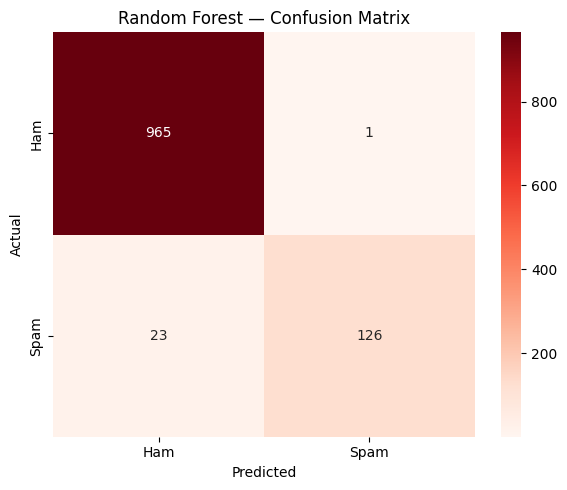


Best model: Random Forest (97.85% accuracy)


In [ ]:
from sklearn.metrics import confusion_matrix

best_model_name = max(results, key=results.get)
best_pipe = pipelines[best_model_name]
best_preds = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title(f'{best_model_name} — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\nBest model: {best_model_name} ({results[best_model_name]*100:.2f}% accuracy)")

Cell 11 — Visualize TF-IDF top spam words

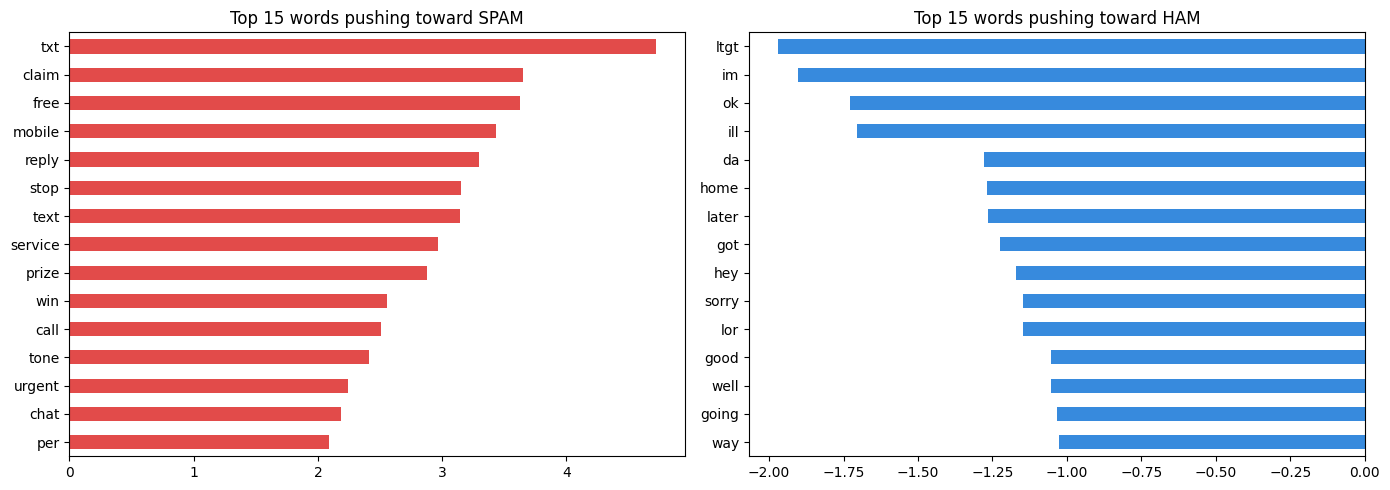

In [ ]:
# Show which words the Logistic Regression model weighted highest for spam
lr_pipe = pipelines['Logistic Regression']
lr_model = lr_pipe.named_steps['model']
tfidf_step = lr_pipe.named_steps['tfidf']

feature_names = tfidf_step.get_feature_names_out()
coefs = lr_model.coef_[0]

# Positive coef = pushes toward SPAM
# Negative coef = pushes toward HAM
top_spam = pd.Series(coefs, index=feature_names).nlargest(15)
top_ham  = pd.Series(coefs, index=feature_names).nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_spam.plot(kind='barh', ax=axes[0], color='#E24B4A')
axes[0].set_title('Top 15 words pushing toward SPAM')
axes[0].invert_yaxis()

top_ham.plot(kind='barh', ax=axes[1], color='#378ADD')
axes[1].set_title('Top 15 words pushing toward HAM')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Cell 12 — Predict your own messages!

In [ ]:
def classify_message(text, pipeline=None):
    if pipeline is None:
        pipeline = pipelines['Logistic Regression']

    cleaned = preprocess_text(text)
    pred    = pipeline.predict([cleaned])[0]
    prob    = pipeline.predict_proba([cleaned])[0]

    label = "SPAM 🚨" if pred == 1 else "HAM ✅"
    print(f"Message : {text}")
    print(f"Cleaned : {cleaned}")
    print(f"Result  : {label}")
    print(f"Ham prob: {prob[0]*100:.1f}%  |  Spam prob: {prob[1]*100:.1f}%")
    print()

# Test with your own messages!
classify_message("Congratulations! You've won a FREE iPhone. Call now to claim your prize!")
classify_message("Hey, are you coming to the study group meeting tomorrow?")
classify_message("URGENT: Your account will be suspended. Click here immediately.")
classify_message("Can you pick up some groceries on your way home?")
classify_message("Win £1000 cash prize! Text WIN to 87222 now!!!")

Message : Congratulations! You've won a FREE iPhone. Call now to claim your prize!
Cleaned : congratulation youve free iphone call claim prize
Result  : SPAM 🚨
Ham prob: 10.7%  |  Spam prob: 89.3%

Message : Hey, are you coming to the study group meeting tomorrow?
Cleaned : hey coming study group meeting tomorrow
Result  : HAM ✅
Ham prob: 97.4%  |  Spam prob: 2.6%

Message : URGENT: Your account will be suspended. Click here immediately.
Cleaned : urgent account suspended click immediately
Result  : HAM ✅
Ham prob: 68.6%  |  Spam prob: 31.4%

Message : Can you pick up some groceries on your way home?
Cleaned : pick grocery way home
Result  : HAM ✅
Ham prob: 97.6%  |  Spam prob: 2.4%

Message : Win £1000 cash prize! Text WIN to 87222 now!!!
Cleaned : win cash prize text win
Result  : SPAM 🚨
Ham prob: 14.9%  |  Spam prob: 85.1%

